# 문제 5 — 4x4 동차변환 모듈과 최소자승법

회전과 병진을 **한 행렬로 묶는** 것이 동차변환입니다.

$$T=\begin{bmatrix}R & \mathbf{t}\\ \mathbf{0}^{\mathsf{T}} & 1\end{bmatrix}\in\mathbb{R}^{4\times 4}$$

이렇게 묶으면 여러 좌표계를 지나는 변환을 **행렬 곱 하나로 연결**할 수 있습니다(문제 6).

이 노트북에서는 `make_T`, `inv_T` 를 만들어 `src/transform.py` 로 내보내고,
점과 방향의 차이, 합성 순서, 속도 비교, 최소자승법까지 다룹니다.

In [3]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import rot_x, rot_y, rot_z
from src.transform import (inv_T, inv_T_batch, least_squares_normal_equation, make_T, rmse,
                           to_homogeneous, transform_direction, transform_point,
                           transform_points)
from src.vectors import det

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


def draw_frame(ax, T, scale=0.35, alpha=1.0, name=""):
    """동차변환 T 가 나타내는 좌표계를 그린다."""
    o = T[:3, 3]
    colors = ["r", "g", "b"]
    for i in range(3):
        v = T[:3, i] * scale
        ax.quiver(*o, *v, color=colors[i], alpha=alpha, arrow_length_ratio=0.18)
    if name:
        ax.text(*(o + 0.05), name, fontsize=9)


def setup_axes(ax, title, lim=1.0):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


print("준비 완료")

준비 완료


## 5-1. `make_T` 와 `inv_T` — 역변환은 전치로 끝난다

역변환을 일반 역행렬로 구할 필요가 없습니다.
$R$ 이 직교행렬이라 $R^{-1}=R^{\mathsf{T}}$ 이기 때문입니다.

$$T^{-1}=\begin{bmatrix}R^{\mathsf{T}} & -R^{\mathsf{T}}\mathbf{t}\\ \mathbf{0}^{\mathsf{T}} & 1\end{bmatrix}$$

유도: $T^{-1}$ 을 $\begin{bmatrix}S&\mathbf{u}\\0&1\end{bmatrix}$ 로 두고 $TT^{-1}=I$ 를 쓰면
$RS=I \Rightarrow S=R^{\mathsf{T}}$, $R\mathbf{u}+\mathbf{t}=\mathbf{0} \Rightarrow \mathbf{u}=-R^{\mathsf{T}}\mathbf{t}$.

의미도 직관적입니다 — "돌린 것을 되돌리고(전치), 옮긴 것을 되돌린 좌표계에서 빼준다".

In [4]:
R = rot_z(np.deg2rad(45.0)) @ rot_y(np.deg2rad(-30.0)) @ rot_x(np.deg2rad(15.0))
t = np.array([0.3, -0.2, 0.45])

T = make_T(R, t)
Ti = inv_T(T)

print("T =\n", T)
print("\ninv_T(T) =\n", Ti)
print("\nT @ inv_T(T) =\n", T @ Ti)
print("\nnp.linalg.inv(T) =\n", np.linalg.inv(T), "  # 검산용")
print("\n두 역변환의 최대 차이 :", format(np.max(np.abs(Ti - np.linalg.inv(T))), ".3e"))

T =
 [[ 0.612372 -0.774519 -0.158494  0.3     ]
 [ 0.612372  0.591506 -0.524519 -0.2     ]
 [ 0.5       0.224144  0.836516  0.45    ]
 [ 0.        0.        0.        1.      ]]

inv_T(T) =
 [[ 0.612372  0.612372  0.5      -0.286237]
 [-0.774519  0.591506  0.224144  0.249792]
 [-0.158494 -0.524519  0.836516 -0.433788]
 [ 0.        0.        0.        1.      ]]

T @ inv_T(T) =
 [[ 1. -0. -0. -0.]
 [-0.  1. -0.  0.]
 [-0. -0.  1.  0.]
 [ 0.  0.  0.  1.]]

np.linalg.inv(T) =
 [[ 0.612372  0.612372  0.5      -0.286237]
 [-0.774519  0.591506  0.224144  0.249792]
 [-0.158494 -0.524519  0.836516 -0.433788]
 [ 0.        0.        0.        1.      ]]   # 검산용

두 역변환의 최대 차이 : 1.110e-16


In [5]:
# --- 검증 ---
ok = check("① T @ inv_T(T) == I", np.allclose(T @ Ti, np.eye(4)))
ok &= check("① inv_T(T) @ T == I", np.allclose(Ti @ T, np.eye(4)))
ok &= check("② 일반 역행렬 np.linalg.inv 와 일치", np.allclose(Ti, np.linalg.inv(T)))
ok &= check("역변환의 회전 부분도 회전행렬 (det = 1)", np.isclose(det(Ti[:3, :3]), 1.0))
ok &= check("마지막 행이 (0,0,0,1)", np.allclose(Ti[3], [0, 0, 0, 1]))
ok &= check("inv_T(inv_T(T)) == T", np.allclose(inv_T(Ti), T))

# 무작위 200개 변환에서도 성립하는지
rand_ok = True
for _ in range(200):
    Rr = rot_z(rng.uniform(-np.pi, np.pi)) @ rot_y(rng.uniform(-np.pi, np.pi)) @ rot_x(rng.uniform(-np.pi, np.pi))
    Tr = make_T(Rr, rng.standard_normal(3))
    rand_ok &= bool(np.allclose(inv_T(Tr) @ Tr, np.eye(4)) and np.allclose(inv_T(Tr), np.linalg.inv(Tr)))
ok &= check("무작위 200개 변환에서 모두 성립", rand_ok)
print("\n5-1 전체 통과:", ok)

[PASS] ① T @ inv_T(T) == I
[PASS] ① inv_T(T) @ T == I
[PASS] ② 일반 역행렬 np.linalg.inv 와 일치
[PASS] 역변환의 회전 부분도 회전행렬 (det = 1)
[PASS] 마지막 행이 (0,0,0,1)
[PASS] inv_T(inv_T(T)) == T
[PASS] 무작위 200개 변환에서 모두 성립

5-1 전체 통과: True


## 5-2. 점과 방향의 차이 — 마지막 성분 1 vs 0

동차좌표의 네 번째 성분 $w$ 가 의미를 가릅니다.

$$T\begin{bmatrix}\mathbf{p}\\1\end{bmatrix}=\begin{bmatrix}R\mathbf{p}+\mathbf{t}\\1\end{bmatrix}
\qquad\qquad
T\begin{bmatrix}\mathbf{v}\\0\end{bmatrix}=\begin{bmatrix}R\mathbf{v}\\0\end{bmatrix}$$

병진 $\mathbf{t}$ 는 $w$ 와 곱해지므로 $w=0$ 이면 **자동으로 사라집니다**.

물리적으로 당연합니다. **점(위치)** 은 좌표계 원점이 어디냐에 따라 값이 달라지지만,
**방향(속도·힘·법선벡터)** 은 원점을 옮겨도 변하지 않습니다.
그래서 카메라가 본 물체의 *위치* 는 병진까지 적용해야 하고,
물체 표면의 *법선* 이나 *속도 벡터* 는 회전만 적용해야 합니다.
이걸 헷갈리면 로봇이 물체를 잡을 때 **툴 오프셋만큼 빗나갑니다.**

In [6]:
v = np.array([1.0, 0.0, 0.0])

p_out = transform_point(T, v)        # w = 1
d_out = transform_direction(T, v)    # w = 0

print("입력                 :", v)
print("점으로 변환 (w=1)    :", p_out)
print("방향으로 변환 (w=0)  :", d_out)
print("\n두 결과의 차이        :", p_out - d_out)
print("병진 벡터 t          :", t, " <- 차이가 정확히 t")
print("\n길이 변화 : |v| = {:.6f} -> 방향 {:.6f} (보존), 점 {:.6f} (원점이 옮겨져 의미 없음)".format(
    np.linalg.norm(v), np.linalg.norm(d_out), np.linalg.norm(p_out)))
print("\n동차좌표 확인 :", to_homogeneous(v, 1.0), "vs", to_homogeneous(v, 0.0))

# 두 점의 '차이'는 방향처럼 변환된다
p1, p2 = np.array([1.0, 2.0, 3.0]), np.array([0.5, -1.0, 2.0])
print("\n(p1 - p2) 를 방향으로 변환    :", transform_direction(T, p1 - p2))
print("변환된 p1 - 변환된 p2         :", transform_point(T, p1) - transform_point(T, p2))

입력                 : [1. 0. 0.]
점으로 변환 (w=1)    : [0.912372 0.412372 0.95    ]
방향으로 변환 (w=0)  : [0.612372 0.612372 0.5     ]

두 결과의 차이        : [ 0.3  -0.2   0.45]
병진 벡터 t          : [ 0.3  -0.2   0.45]  <- 차이가 정확히 t

길이 변화 : |v| = 1.000000 -> 방향 1.000000 (보존), 점 1.380208 (원점이 옮겨져 의미 없음)

동차좌표 확인 : [1. 0. 0. 1.] vs [1. 0. 0. 0.]

(p1 - p2) 를 방향으로 변환    : [-2.175865  1.556186  1.758948]
변환된 p1 - 변환된 p2         : [-2.175865  1.556186  1.758948]


In [7]:
# --- 검증 ---
ok = check("점과 방향의 결과가 다르다", not np.allclose(p_out, d_out))
ok &= check("차이가 정확히 병진 벡터 t", np.allclose(p_out - d_out, t))
ok &= check("방향은 길이가 보존된다", np.isclose(np.linalg.norm(d_out), np.linalg.norm(v)))
ok &= check("방향 변환은 회전만 적용 (R @ v)", np.allclose(d_out, R @ v))
ok &= check("점 변환은 R @ p + t", np.allclose(p_out, R @ v + t))
ok &= check("두 점의 차이는 방향처럼 변환된다",
            np.allclose(transform_direction(T, p1 - p2),
                        transform_point(T, p1) - transform_point(T, p2)))
ok &= check("원점(0,0,0)을 점으로 변환하면 t", np.allclose(transform_point(T, [0, 0, 0]), t))
ok &= check("영벡터를 방향으로 변환하면 영벡터", np.allclose(transform_direction(T, [0, 0, 0]), 0.0))
print("\n5-2 전체 통과:", ok)

[PASS] 점과 방향의 결과가 다르다
[PASS] 차이가 정확히 병진 벡터 t
[PASS] 방향은 길이가 보존된다
[PASS] 방향 변환은 회전만 적용 (R @ v)
[PASS] 점 변환은 R @ p + t
[PASS] 두 점의 차이는 방향처럼 변환된다
[PASS] 원점(0,0,0)을 점으로 변환하면 t
[PASS] 영벡터를 방향으로 변환하면 영벡터

5-2 전체 통과: True


## 5-3. 합성 순서가 바뀌면 결과가 다르다

회전과 마찬가지로 동차변환의 곱도 교환법칙이 성립하지 않습니다.
특히 **회전이 병진을 끌고 돕니다**.

$$T_1T_2=\begin{bmatrix}R_1R_2 & R_1\mathbf{t}_2+\mathbf{t}_1\\0&1\end{bmatrix}
\qquad
T_2T_1=\begin{bmatrix}R_2R_1 & R_2\mathbf{t}_1+\mathbf{t}_2\\0&1\end{bmatrix}$$

회전 부분이 다른 것은 물론이고, 병진 부분도 **어느 회전이 어느 병진에 걸리느냐**가 달라집니다.
"1 m 앞으로 간 뒤 90도 돌기" 와 "90도 돈 뒤 1 m 앞으로 가기" 가 다른 것과 같습니다.

In [8]:
# 병진 벡터가 회전축과 나란하면 순서를 바꿔도 병진이 우연히 같아진다.
# 두 축 모두에 성분이 걸리도록 잡아야 차이가 드러난다.
T1 = make_T(rot_z(np.deg2rad(90.0)), [0.5, 0.2, 0.0])    # z 90도 회전 + (0.5, 0.2, 0) 이동
T2 = make_T(rot_x(np.deg2rad(90.0)), [0.1, 0.0, 0.4])    # x 90도 회전 + (0.1, 0, 0.4) 이동

C12 = T1 @ T2
C21 = T2 @ T1

print("T1 @ T2 =\n", C12)
print("\nT2 @ T1 =\n", C21)
print("\n같은가 :", np.allclose(C12, C21))
print("회전 부분 차이 (최대) :", format(np.max(np.abs(C12[:3, :3] - C21[:3, :3])), ".4f"))
print("병진 부분 : {} vs {}".format(C12[:3, 3], C21[:3, 3]))
print("\n공식 확인 R1 t2 + t1 =", T1[:3, :3] @ T2[:3, 3] + T1[:3, 3], "== ", C12[:3, 3])

T1 @ T2 =
 [[ 0.  -0.   1.   0.5]
 [ 1.   0.  -0.   0.3]
 [ 0.   1.   0.   0.4]
 [ 0.   0.   0.   1. ]]

T2 @ T1 =
 [[ 0.  -1.   0.   0.6]
 [ 0.   0.  -1.   0. ]
 [ 1.   0.   0.   0.6]
 [ 0.   0.   0.   1. ]]

같은가 : False
회전 부분 차이 (최대) : 1.0000
병진 부분 : [0.5 0.3 0.4] vs [0.6 0.  0.6]

공식 확인 R1 t2 + t1 = [0.5 0.3 0.4] ==  [0.5 0.3 0.4]


/tmp/ipykernel_25691/4191168780.py:22: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/4191168780.py:22: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/4191168780.py:22: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/4191168780.py:22: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/4191168780.py:22: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/4191168780.py:22: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/4191168780.py:22: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  fig.ti

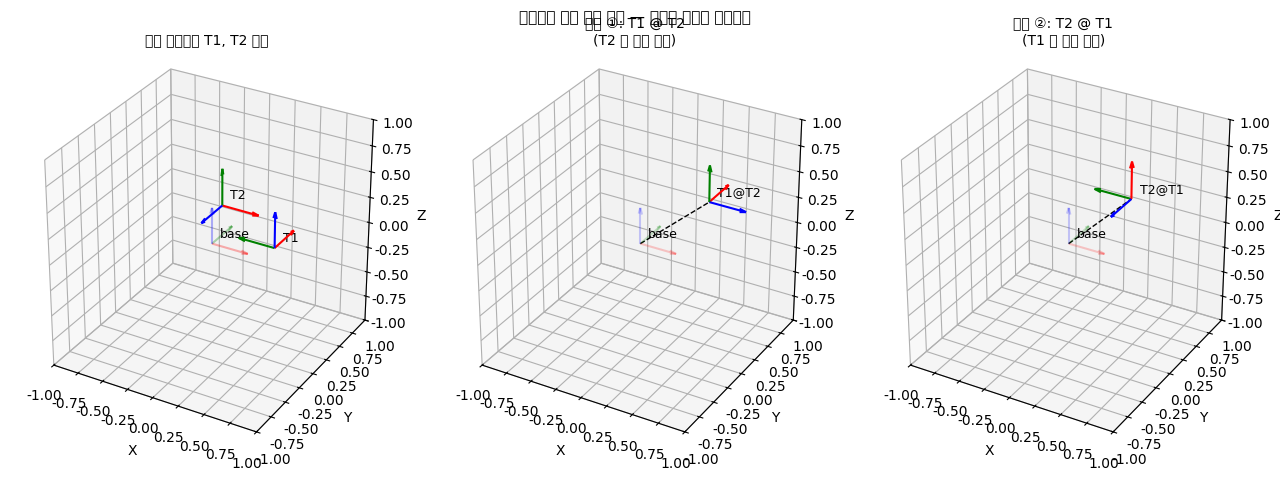

In [9]:
fig = plt.figure(figsize=(13, 4.6))

ax = fig.add_subplot(1, 3, 1, projection="3d")
setup_axes(ax, "기준 좌표계와 T1, T2 각각")
draw_frame(ax, np.eye(4), alpha=0.3, name="base")
draw_frame(ax, T1, name="T1")
draw_frame(ax, T2, name="T2")

ax = fig.add_subplot(1, 3, 2, projection="3d")
setup_axes(ax, "순서 ①: T1 @ T2\n(T2 를 먼저 적용)")
draw_frame(ax, np.eye(4), alpha=0.2, name="base")
draw_frame(ax, C12, name="T1@T2")
ax.plot(*np.array([[0, 0, 0], C12[:3, 3]]).T, "k--", lw=1)

ax = fig.add_subplot(1, 3, 3, projection="3d")
setup_axes(ax, "순서 ②: T2 @ T1\n(T1 을 먼저 적용)")
draw_frame(ax, np.eye(4), alpha=0.2, name="base")
draw_frame(ax, C21, name="T2@T1")
ax.plot(*np.array([[0, 0, 0], C21[:3, 3]]).T, "k--", lw=1)

fig.suptitle("동차변환 합성 순서 비교 — 자세도 위치도 달라진다", fontsize=11)
fig.tight_layout()
plt.show()

In [10]:
# --- 검증 ---
ok = check("두 합성 결과가 다르다", not np.allclose(C12, C21))
ok &= check("병진 부분이 다르다", not np.allclose(C12[:3, 3], C21[:3, 3]))
ok &= check("합성 공식 R1 t2 + t1 이 맞다",
            np.allclose(C12[:3, 3], T1[:3, :3] @ T2[:3, 3] + T1[:3, 3]))
ok &= check("두 결과 모두 유효한 동차변환 (회전부 det = 1)",
            np.isclose(det(C12[:3, :3]), 1.0) and np.isclose(det(C21[:3, :3]), 1.0))
ok &= check("역변환 순서는 뒤집힌다: (T1 T2)^-1 == T2^-1 T1^-1",
            np.allclose(inv_T(C12), inv_T(T2) @ inv_T(T1)))
print("\n5-3 전체 통과:", ok)

[PASS] 두 합성 결과가 다르다
[PASS] 병진 부분이 다르다
[PASS] 합성 공식 R1 t2 + t1 이 맞다
[PASS] 두 결과 모두 유효한 동차변환 (회전부 det = 1)
[PASS] 역변환 순서는 뒤집힌다: (T1 T2)^-1 == T2^-1 T1^-1

5-3 전체 통과: True


## 5-4. `inv_T` vs 일반 역행렬 — 연산량 비교

| 방법 | 하는 일 | 연산량 |
|---|---|---|
| `inv_T` | 3x3 전치 + 3x3 @ 3x1 곱 + 부호 | 곱셈 9 회 + 덧셈 6 회 정도, **약 15 flops** |
| `np.linalg.inv` | 4x4 LU 분해 + 전/후진 대입 | $\sim\tfrac{2}{3}\cdot 4^3 \approx 43$ flops + LAPACK 호출 |

**다만 4x4 하나만 뒤집는 단건 호출로는 이 차이가 측정되지 않습니다.**
두 방법 모두 실제 연산은 수십 flops(나노초 단위)뿐이고,
시간의 대부분은 **파이썬 함수 호출과 NumPy 배열 생성 오버헤드(마이크로초 단위)** 이기 때문입니다.
즉 단건 벤치마크는 연산량이 아니라 오버헤드를 재고 있는 셈입니다.

실제 차이를 보려면 **오버헤드를 상수로 만들고 연산량만 남겨야** 합니다.
그래서 `(N, 4, 4)` 변환 묶음을 한 번에 뒤집는 `inv_T_batch` 로 비교합니다
(`np.linalg.inv` 도 스택 입력을 지원합니다).
로봇 제어 루프에서 링크 수십 개의 변환을 매 주기 뒤집는 상황이 정확히 이 형태입니다.

In [11]:
N_REPEAT = 20000


def bench(fn, repeat):
    """워밍업 후 repeat 번 재서 최솟값을 쓴다."""
    fn()
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - t0)
    return best


t_fast = bench(lambda: inv_T(T), N_REPEAT)
t_generic = bench(lambda: np.linalg.inv(T), N_REPEAT)

print("[단건 호출 — 오버헤드가 지배]")
print("{:<26}{:>16}".format("방법", "1회 시간 [us]"))
print("-" * 42)
print("{:<26}{:>16.3f}".format("inv_T (전치 공식)", t_fast * 1e6))
print("{:<26}{:>16.3f}".format("np.linalg.inv", t_generic * 1e6))
print("-> 비율 {:.2f} 배. 수십 flops 의 차이는 마이크로초 단위 호출 오버헤드에 묻힌다.".format(
    t_generic / t_fast))

[단건 호출 — 오버헤드가 지배]
방법                              1회 시간 [us]
------------------------------------------
inv_T (전치 공식)                        2.884
np.linalg.inv                        2.018
-> 비율 0.70 배. 수십 flops 의 차이는 마이크로초 단위 호출 오버헤드에 묻힌다.


In [12]:
# 배치로 뒤집어 오버헤드를 상수화하고 연산량만 비교
N_BATCH = 2000
Ts = np.stack([make_T(rot_z(a) @ rot_y(b_) @ rot_x(c), rng.standard_normal(3))
               for a, b_, c in rng.uniform(-np.pi, np.pi, (N_BATCH, 3))])

t_batch_fast = bench(lambda: inv_T_batch(Ts), 200)
t_batch_generic = bench(lambda: np.linalg.inv(Ts), 200)

print("[배치 {} 개 — 연산량이 지배]".format(N_BATCH))
print("{:<26}{:>16}{:>18}".format("방법", "시간 [ms]", "1개당 [us]"))
print("-" * 60)
print("{:<26}{:>16.3f}{:>18.3f}".format(
    "inv_T_batch (전치 공식)", t_batch_fast * 1e3, t_batch_fast / N_BATCH * 1e6))
print("{:<26}{:>16.3f}{:>18.3f}".format(
    "np.linalg.inv (스택)", t_batch_generic * 1e3, t_batch_generic / N_BATCH * 1e6))
print("-> 전치 공식이 {:.1f} 배 빠르다. 오버헤드가 상수가 되자 연산량 차이가 그대로 드러난다.".format(
    t_batch_generic / t_batch_fast))

print("\n[정확도] 전치 공식은 회전부 직교성이 구조적으로 보존된다")
print("  inv_T        직교성 오차 : {:.2e}".format(
    np.max(np.abs(inv_T(T)[:3, :3].T @ inv_T(T)[:3, :3] - np.eye(3)))))
print("  np.linalg.inv 직교성 오차 : {:.2e}".format(
    np.max(np.abs(np.linalg.inv(T)[:3, :3].T @ np.linalg.inv(T)[:3, :3] - np.eye(3)))))

[배치 2000 개 — 연산량이 지배]
방법                                 시간 [ms]          1개당 [us]
------------------------------------------------------------
inv_T_batch (전치 공식)                  0.045             0.022
np.linalg.inv (스택)                   0.315             0.158
-> 전치 공식이 7.0 배 빠르다. 오버헤드가 상수가 되자 연산량 차이가 그대로 드러난다.

[정확도] 전치 공식은 회전부 직교성이 구조적으로 보존된다
  inv_T        직교성 오차 : 1.11e-16
  np.linalg.inv 직교성 오차 : 2.22e-16


In [13]:
# --- 검증 ---
ok = check("배치에서 inv_T_batch 가 일반 역행렬보다 빠르다", t_batch_fast < t_batch_generic)
ok &= check("inv_T 와 일반 역행렬의 결과가 같다", np.allclose(inv_T(T), np.linalg.inv(T)))
ok &= check("inv_T_batch 결과 == np.linalg.inv 스택 결과",
            np.allclose(inv_T_batch(Ts), np.linalg.inv(Ts)))
ok &= check("inv_T_batch 결과 == inv_T 를 하나씩 적용한 결과",
            np.allclose(inv_T_batch(Ts[:50]), np.array([inv_T(t_) for t_ in Ts[:50]])))
ok &= check("inv_T 결과의 회전부가 완전한 직교",
            np.max(np.abs(inv_T(T)[:3, :3].T @ inv_T(T)[:3, :3] - np.eye(3))) < 1e-15)
print("\n5-4 전체 통과:", ok)

[PASS] 배치에서 inv_T_batch 가 일반 역행렬보다 빠르다
[PASS] inv_T 와 일반 역행렬의 결과가 같다
[PASS] inv_T_batch 결과 == np.linalg.inv 스택 결과
[PASS] inv_T_batch 결과 == inv_T 를 하나씩 적용한 결과
[PASS] inv_T 결과의 회전부가 완전한 직교

5-4 전체 통과: True


## 5-5. 최소자승법 — 과결정 캘리브레이션 문제

**상황**: 카메라와 로봇 base 양쪽에서 좌표를 아는 대응점 $N$ 개가 있고,
이 대응을 설명하는 변환 $M=[R\,|\,\mathbf{t}]$ (12개 미지수)를 찾고 싶습니다.
측정에는 노이즈가 섞여 있고 대응점은 $N=30$ 개라 **방정식이 $3N=90$ 개, 미지수가 12 개**인
과결정(overdetermined) 문제입니다. 정확히 만족하는 해는 없으므로 **오차 제곱합을 최소화**합니다.

각 대응점은 다음 3 개의 선형방정식을 줍니다.

$$\mathbf{p}_{base} = M\begin{bmatrix}\mathbf{p}_{cam}\\1\end{bmatrix}
\;\Longrightarrow\;
\underbrace{(I_3\otimes[\mathbf{p}_{cam}^{\mathsf{T}}\;1])}_{3\times 12}\,\mathrm{vec}(M)=\mathbf{p}_{base}$$

최소자승해는 **정규방정식**에서 나옵니다.

$$\min_x\lVert A\mathbf{x}-\mathbf{b}\rVert^2 \;\Longrightarrow\;
A^{\mathsf{T}}A\,\mathbf{x}=A^{\mathsf{T}}\mathbf{b}$$

유도: 잔차 $\mathbf{r}=\mathbf{b}-A\mathbf{x}$ 가 최소일 때
$\mathbf{r}$ 은 $A$ 의 **열공간에 수직**이어야 하므로 $A^{\mathsf{T}}\mathbf{r}=\mathbf{0}$ 입니다.

In [14]:
N_PTS = 30
NOISE = 1e-3          # 1 mm 측정 노이즈

T_true = make_T(rot_z(np.deg2rad(25.0)) @ rot_x(np.deg2rad(-40.0)), [0.12, -0.35, 0.68])
M_true = T_true[:3, :]                                   # 참값 3x4

P_cam = rng.uniform(-0.5, 0.5, size=(N_PTS, 3))
P_base = transform_points(T_true, P_cam) + NOISE * rng.standard_normal((N_PTS, 3))

# 설계행렬 A (3N x 12) 와 관측 b (3N,)
Ph = to_homogeneous(P_cam, 1.0)                          # (N, 4)
A_ls = np.vstack([np.kron(np.eye(3), row.reshape(1, 4)) for row in Ph])
b_ls = P_base.reshape(-1)

print("설계행렬 A :", A_ls.shape, " 관측 b :", b_ls.shape, " 미지수 :", A_ls.shape[1])
print("과결정 여부 : 방정식 {} 개 > 미지수 {} 개 -> {}".format(
    A_ls.shape[0], A_ls.shape[1], A_ls.shape[0] > A_ls.shape[1]))
print("rank(A) =", np.linalg.matrix_rank(A_ls), "(full column rank 여야 유일한 최소자승해)")

x_hat, residual = least_squares_normal_equation(A_ls, b_ls)
M_hat = x_hat.reshape(3, 4)

x_ref, res_ref, rank_ref, sv = np.linalg.lstsq(A_ls, b_ls, rcond=None)   # 비교 대상

print("\n추정한 M =\n", M_hat)
print("\n참값 M   =\n", M_true)
print("\nM 성분 최대 오차 : {:.3e}".format(np.max(np.abs(M_hat - M_true))))
print("정규방정식 해 vs lstsq 최대 차이 : {:.3e}".format(np.max(np.abs(x_hat - x_ref))))

rmse_val = rmse(residual)
print("\n잔차 RMSE          : {:.6e} m  ({:.4f} mm)".format(rmse_val, rmse_val * 1e3))
print("주입한 노이즈 sigma : {:.6e} m  ({:.4f} mm)".format(NOISE, NOISE * 1e3))
print("잔차가 열공간에 수직 : |A^T r| = {:.3e}".format(np.linalg.norm(A_ls.T @ residual)))

# 추정된 회전 부분이 얼마나 회전행렬에 가까운가 (노이즈 때문에 정확히는 아님)
R_hat = M_hat[:3, :3]
print("\n추정 R 의 det        : {:.8f}  (1 에 가까울수록 좋음)".format(det(R_hat)))
print("추정 R 의 직교성 오차 : {:.3e}".format(np.max(np.abs(R_hat.T @ R_hat - np.eye(3)))))

설계행렬 A : (90, 12)  관측 b : (90,)  미지수 : 12
과결정 여부 : 방정식 90 개 > 미지수 12 개 -> True
rank(A) = 12 (full column rank 여야 유일한 최소자승해)

추정한 M =
 [[ 0.90645  -0.323909 -0.271398  0.119996]
 [ 0.422983  0.695233  0.581359 -0.3497  ]
 [-0.000455 -0.643855  0.766608  0.679859]]

참값 M   =
 [[ 0.906308 -0.323744 -0.271654  0.12    ]
 [ 0.422618  0.694272  0.582563 -0.35    ]
 [ 0.       -0.642788  0.766044  0.68    ]]

M 성분 최대 오차 : 1.204e-03
정규방정식 해 vs lstsq 최대 차이 : 1.021e-14

잔차 RMSE          : 8.605755e-04 m  (0.8606 mm)
주입한 노이즈 sigma : 1.000000e-03 m  (1.0000 mm)
잔차가 열공간에 수직 : |A^T r| = 1.302e-15

추정 R 의 det        : 1.00134962  (1 에 가까울수록 좋음)
추정 R 의 직교성 오차 : 2.815e-03


/tmp/ipykernel_25691/347966547.py:21: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/347966547.py:21: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/347966547.py:21: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/347966547.py:21: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/347966547.py:21: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/347966547.py:21: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_25691/347966547.py:21: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.tight_layo

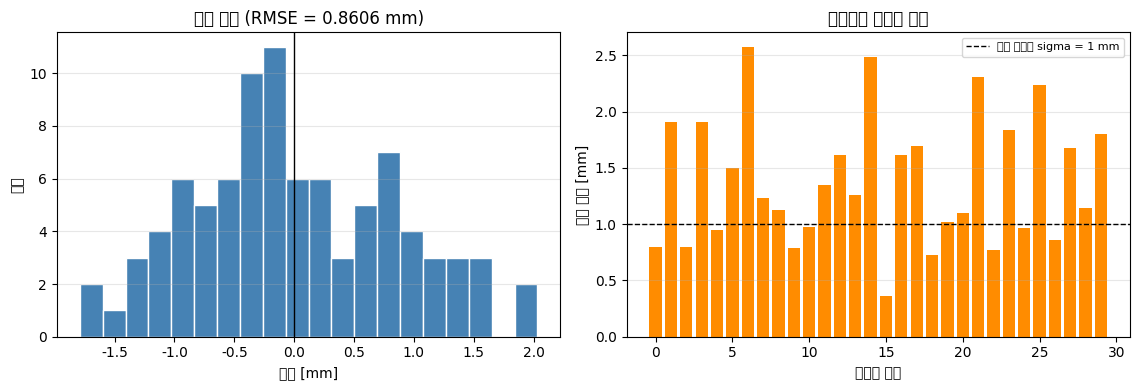

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

pred = (A_ls @ x_hat).reshape(-1, 3)
err_per_point = np.linalg.norm(P_base - pred, axis=1)

axes[0].hist(residual * 1e3, bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="k", lw=1)
axes[0].set_xlabel("잔차 [mm]")
axes[0].set_ylabel("빈도")
axes[0].set_title("잔차 분포 (RMSE = {:.4f} mm)".format(rmse_val * 1e3))
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(np.arange(N_PTS), err_per_point * 1e3, color="darkorange")
axes[1].axhline(NOISE * 1e3, ls="--", color="k", lw=1, label="주입 노이즈 sigma = 1 mm")
axes[1].set_xlabel("대응점 번호")
axes[1].set_ylabel("점별 오차 [mm]")
axes[1].set_title("대응점별 재투영 오차")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [16]:
# --- 검증 ---
ok = check("과결정 문제다 (식 90개 > 미지수 12개)", A_ls.shape[0] > A_ls.shape[1])
ok &= check("정규방정식 해가 np.linalg.lstsq 와 일치", np.allclose(x_hat, x_ref))
ok &= check("잔차가 A 의 열공간에 수직 (A^T r = 0)", np.allclose(A_ls.T @ residual, 0.0, atol=1e-9))
ok &= check("추정한 M 이 참값에 가깝다 (오차 < 3 mm 수준)", np.max(np.abs(M_hat - M_true)) < 3e-3)
ok &= check("잔차 RMSE 가 주입 노이즈와 같은 자릿수", 0.2 * NOISE < rmse_val < 2.0 * NOISE)
ok &= check("추정 회전부의 det 가 1 에 가깝다", abs(det(R_hat) - 1.0) < 1e-2)
ok &= check("최소자승해가 실제로 최소 (임의 교란보다 잔차가 작다)",
            all(np.linalg.norm(b_ls - A_ls @ (x_hat + 1e-3 * rng.standard_normal(12)))
                > np.linalg.norm(residual) for _ in range(20)))
print("\n5-5 전체 통과:", ok)

[PASS] 과결정 문제다 (식 90개 > 미지수 12개)
[PASS] 정규방정식 해가 np.linalg.lstsq 와 일치
[PASS] 잔차가 A 의 열공간에 수직 (A^T r = 0)
[PASS] 추정한 M 이 참값에 가깝다 (오차 < 3 mm 수준)
[PASS] 잔차 RMSE 가 주입 노이즈와 같은 자릿수
[PASS] 추정 회전부의 det 가 1 에 가깝다
[PASS] 최소자승해가 실제로 최소 (임의 교란보다 잔차가 작다)

5-5 전체 통과: True


## 답안 템플릿 정리

In [17]:
summary = """
1. 역변환 검증: 단위행렬 여부 {a} / 일반 역행렬과 일치 {b}
   (무작위 200개 변환에서도 전수 통과. 공식: T^-1 = [[R^T, -R^T t], [0, 1]])

2. 점 변환 결과: {p} / 방향 변환 결과: {d}
   - 차이의 이유: 병진 t 는 동차좌표의 마지막 성분 w 와 곱해진다. 점은 w=1 이라
     t 가 더해지고, 방향은 w=0 이라 t 가 사라져 회전만 적용된다.
     두 결과의 차이는 정확히 t = {tt}. 위치는 원점에 의존하지만 방향은 의존하지 않는다.

3. 합성 순서 비교 그림: 위 3분할 그림 참조
   T1@T2 병진 {c12} vs T2@T1 병진 {c21} — 회전이 병진을 끌고 돌기 때문에 둘 다 달라진다.

4. inv_T 와 일반 역행렬 속도
   - 단건 호출 : {tf:.3f} us / {tg:.3f} us  (비율 {ratio:.2f} 배 — 호출 오버헤드가 지배해 차이가 없거나 오히려 역전된다)
   - 배치 {nb} 개 : {btf:.3f} ms / {btg:.3f} ms  (전치 공식이 {bratio:.1f} 배 빠름)
   - 차이의 이유: inv_T 는 3x3 전치 + 행렬-벡터 곱 하나로 끝나는 약 15 flops 의 닫힌 공식이고,
     np.linalg.inv 는 4x4 LU 분해와 전/후진 대입을 돌린다(약 43 flops).
     단건 호출에서는 이 수십 flops 차이가 마이크로초 단위의 파이썬/NumPy 호출 오버헤드에
     묻혀 측정되지 않는다. 배치로 오버헤드를 상수화하면 연산량 차이가 그대로 드러난다.
     정확도 면에서도 inv_T 는 전치라 회전부 직교성이 구조적으로 보존된다.

5. 최소자승 해: 3x4 변환 M 12개 성분, 참값 대비 최대 오차 {merr:.3e}
   - lstsq 와 일치: {same} (최대 차이 {ldiff:.3e})
   - 잔차 RMSE: {rm:.6e} m = {rmm:.4f} mm  (주입 노이즈 sigma = 1.0 mm 와 같은 자릿수)
   - 정규방정식 A^T A x = A^T b 는 잔차가 A 의 열공간에 수직이라는 조건에서 나온다.
     실제로 |A^T r| = {perp:.3e} 로 0 이다.
""".format(
    a=bool(np.allclose(T @ Ti, np.eye(4))),
    b=bool(np.allclose(Ti, np.linalg.inv(T))),
    p=np.round(p_out, 6), d=np.round(d_out, 6), tt=t,
    c12=np.round(C12[:3, 3], 4), c21=np.round(C21[:3, 3], 4),
    tf=t_fast * 1e6, tg=t_generic * 1e6, ratio=t_generic / t_fast,
    nb=N_BATCH, btf=t_batch_fast * 1e3, btg=t_batch_generic * 1e3,
    bratio=t_batch_generic / t_batch_fast,
    merr=float(np.max(np.abs(M_hat - M_true))),
    same=bool(np.allclose(x_hat, x_ref)),
    ldiff=float(np.max(np.abs(x_hat - x_ref))),
    rm=rmse_val, rmm=rmse_val * 1e3,
    perp=float(np.linalg.norm(A_ls.T @ residual)),
)
print(summary)


1. 역변환 검증: 단위행렬 여부 True / 일반 역행렬과 일치 True
   (무작위 200개 변환에서도 전수 통과. 공식: T^-1 = [[R^T, -R^T t], [0, 1]])

2. 점 변환 결과: [0.912372 0.412372 0.95    ] / 방향 변환 결과: [0.612372 0.612372 0.5     ]
   - 차이의 이유: 병진 t 는 동차좌표의 마지막 성분 w 와 곱해진다. 점은 w=1 이라
     t 가 더해지고, 방향은 w=0 이라 t 가 사라져 회전만 적용된다.
     두 결과의 차이는 정확히 t = [ 0.3  -0.2   0.45]. 위치는 원점에 의존하지만 방향은 의존하지 않는다.

3. 합성 순서 비교 그림: 위 3분할 그림 참조
   T1@T2 병진 [0.5 0.3 0.4] vs T2@T1 병진 [0.6 0.  0.6] — 회전이 병진을 끌고 돌기 때문에 둘 다 달라진다.

4. inv_T 와 일반 역행렬 속도
   - 단건 호출 : 2.884 us / 2.018 us  (비율 0.70 배 — 호출 오버헤드가 지배해 차이가 없거나 오히려 역전된다)
   - 배치 2000 개 : 0.045 ms / 0.315 ms  (전치 공식이 7.0 배 빠름)
   - 차이의 이유: inv_T 는 3x3 전치 + 행렬-벡터 곱 하나로 끝나는 약 15 flops 의 닫힌 공식이고,
     np.linalg.inv 는 4x4 LU 분해와 전/후진 대입을 돌린다(약 43 flops).
     단건 호출에서는 이 수십 flops 차이가 마이크로초 단위의 파이썬/NumPy 호출 오버헤드에
     묻혀 측정되지 않는다. 배치로 오버헤드를 상수화하면 연산량 차이가 그대로 드러난다.
     정확도 면에서도 inv_T 는 전치라 회전부 직교성이 구조적으로 보존된다.

5. 최소자승 해: 3x4 변환 M 12개 성분, 참값 대비 최대 오차 1.204e-03
   - lstsq 와 일치: True (최대 차이 1.021e-14)
  